# 02. Tiền xử lý dữ liệu (Preprocessing)

**Mục tiêu của notebook này:**
- Xây dựng pipeline tiền xử lý nhất quán cho dữ liệu ảnh lúa/cà phê.
- Loại ảnh lỗi, ảnh trùng lặp và ảnh quá mờ để tăng chất lượng dữ liệu.
- **Chia train/val/test trước khi augmentation để tránh data leakage.**
- Chuẩn hóa ảnh (resize + pixel normalization) và lưu về `data/processed/`.
- Thiết kế augmentation cho tập train theo các insights từ quá trình EDA và kế hoạch ban đầu theo proposal:
  - Affine transformation
  - Intensity transformation (brightness/contrast/saturation/hue)
  - Cutout (Random Erasing)
  - MixUp
  - CutMix

**Tỉ lệ chia dữ liệu:** 70% train - 15% validation - 15% test (stratified theo domain + lớp bệnh).

---

### Mục lục nhanh

1. Thiết lập môi trường và cấu hình
2. Thu thập metadata từ dữ liệu thô
3. Làm sạch dữ liệu (invalid/duplicate/blurry)
4. Chia dữ liệu chống leakage
5. Chuẩn hóa ảnh và lưu vào `data/processed/images`
6. Tính mean/std trên train split
7. Thiết lập augmentation cho huấn luyện
8. Tạo sampler cân bằng lớp + lưu preprocessing config

---

## 1. Thiết lập môi trường và cấu hình

Cell này thiết lập import, seed, và đường dẫn dữ liệu để toàn bộ quy trình tiền xử lý chạy tái lập được.

**Nguyên tắc:**
- Đọc dữ liệu từ `data/raw/`.
- Ghi kết quả sang `data/processed/`.
- Không can thiệp vào tập gốc để đảm bảo tính reproducibility.

In [1]:
# ============================================================
# Environment setup
# ============================================================
import os
import sys
import json
import hashlib
import warnings
import importlib.util
from pathlib import Path
from typing import Dict, List

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from PIL import Image, ImageOps, ImageFile, UnidentifiedImageError
from sklearn.model_selection import train_test_split

import torch
from tqdm.auto import tqdm

warnings.filterwarnings("ignore")
ImageFile.LOAD_TRUNCATED_IMAGES = True

# Find project root from current working directory
def find_project_root() -> Path:
    cwd = Path(os.getcwd())
    for candidate in [cwd, cwd.parent, cwd.parent.parent]:
        if (candidate / "src").exists() and (candidate / "notebooks").exists():
            return candidate
    return cwd


def load_module_from_path(module_name: str, module_path: Path):
    spec = importlib.util.spec_from_file_location(module_name, str(module_path))
    if spec is None or spec.loader is None:
        raise ImportError(f"Cannot load module: {module_name} from {module_path}")
    module = importlib.util.module_from_spec(spec)
    spec.loader.exec_module(module)
    return module


PROJECT_ROOT = find_project_root()
sys.path.insert(0, str(PROJECT_ROOT / "src" / "utils"))

config_module = load_module_from_path("project_config", PROJECT_ROOT / "src" / "utils" / "config.py")
utils_module = load_module_from_path("project_utils", PROJECT_ROOT / "src" / "utils" / "utils.py")

RANDOM_SEED = int(config_module.RANDOM_SEED)
RICE_CLASSES = list(config_module.RICE_CLASSES)
COFFEE_CLASSES = list(config_module.COFFEE_CLASSES)
set_seed = utils_module.set_seed

set_seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)
torch.manual_seed(RANDOM_SEED)

RAW_DIR = PROJECT_ROOT / "data" / "raw"
PROCESSED_DIR = PROJECT_ROOT / "data" / "processed"
META_DIR = PROCESSED_DIR / "metadata"
IMG_OUT_DIR = PROCESSED_DIR / "images"

RICE_RAW_DIR = RAW_DIR / "rice_leaf_disease"
COFFEE_RAW_DIR = RAW_DIR / "coffee_leaf_disease"

COFFEE_FOLDER_TO_LABEL = {str(i): name for i, name in enumerate(COFFEE_CLASSES)}
VALID_EXTS = {".jpg", ".jpeg", ".png", ".webp"}

for path in [PROCESSED_DIR, META_DIR, IMG_OUT_DIR]:
    path.mkdir(parents=True, exist_ok=True)

print(f"Project root: {PROJECT_ROOT}")
print(f"Raw data dir: {RAW_DIR}")
print(f"Processed dir: {PROCESSED_DIR}")

Project root: c:\Users\tdat0\Data\Uncategorized_items\ml-vietnam-plant-disease-detection
Raw data dir: c:\Users\tdat0\Data\Uncategorized_items\ml-vietnam-plant-disease-detection\datasets\final
Processed dir: c:\Users\tdat0\Data\Uncategorized_items\ml-vietnam-plant-disease-detection\datasets\processed


c:\Users\tdat0\Data\Uncategorized_items\ml-vietnam-plant-disease-detection\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


---

## 2. Thu thập metadata từ dữ liệu thô

Ở bước này, chúng ta hợp nhất metadata từ hai domain lúa/cà phê về một bảng chung, bao gồm:
- domain
- nhãn bệnh
- kích thước ảnh
- đường dẫn ảnh
- thông tin chất lượng cơ bản

Bảng metadata là đầu vào chính cho bước làm sạch và chia dữ liệu.

### Metadata là gì?

Metadata (siêu dữ liệu) là thông tin mô tả về dữ liệu — ở đây là thông tin về từng ảnh: đường dẫn, kích thước, nhãn lớp, domain, v.v.

### Tại sao cần bảng metadata thống nhất?

Dự án này sử dụng hai nguồn dữ liệu độc lập (lúa và cà phê) với cấu trúc thư mục khác nhau. Việc hợp nhất về một DataFrame chung giúp:
- **Quản lý tập trung** toàn bộ dữ liệu ở một nơi.
- **Dễ thống kê** phân phối lớp, kích thước ảnh, v.v.
- **Làm đầu vào chung** cho bước lọc chất lượng và chia tập.

### Hàm `safe_image_size`

Hàm này dùng thư viện PIL để mở ảnh và đọc kích thước. Nếu ảnh bị lỗi (corrupt, không mở được), hàm trả về giá trị `NaN` thay vì raise exception — giúp pipeline không bị dừng giữa chừng.

In [2]:
# ============================================================
# Build unified metadata table from raw folders
# ============================================================
def safe_image_size(image_path: Path):
    try:
        with Image.open(image_path) as img:
            width, height = img.size
            mode = img.mode
        return width, height, mode, True
    except (UnidentifiedImageError, OSError, ValueError):
        return np.nan, np.nan, "invalid", False


def collect_domain_records(
    domain: str,
    domain_dir: Path,
    folder_to_label: Dict[str, str],
    start_index: int = 0,
    valid_exts: set = VALID_EXTS,
) -> pd.DataFrame:
    records: List[dict] = []
    sample_index = start_index

    for folder_name, label_name in folder_to_label.items():
        class_dir = domain_dir / folder_name
        if not class_dir.exists():
            print(f"[WARN] Missing class folder: {class_dir}")
            continue

        image_files = [
            p for p in class_dir.iterdir()
            if p.is_file() and p.suffix.lower() in valid_exts
        ]

        for image_path in image_files:
            width, height, mode, is_valid = safe_image_size(image_path)
            records.append({
                "sample_id": f"{domain}_{sample_index:07d}",
                "domain": domain,
                "label": label_name,
                "class_folder": folder_name,
                "file_name": image_path.name,
                "image_path": str(image_path),
                "relative_path": str(image_path.relative_to(PROJECT_ROOT)).replace("\\", "/"),
                "file_ext": image_path.suffix.lower(),
                "file_size_bytes": image_path.stat().st_size,
                "width": width,
                "height": height,
                "aspect_ratio": (width / height) if is_valid and height else np.nan,
                "color_mode": mode,
                "is_valid_image": is_valid,
            })
            sample_index += 1

    return pd.DataFrame(records)


rice_map = {cls: cls for cls in RICE_CLASSES}
coffee_map = {str(i): label for i, label in enumerate(COFFEE_CLASSES)}

rice_meta = collect_domain_records(
    domain="rice",
    domain_dir=RICE_RAW_DIR,
    folder_to_label=rice_map,
    start_index=0,
    valid_exts=VALID_EXTS,
)
coffee_meta = collect_domain_records(
    domain="coffee",
    domain_dir=COFFEE_RAW_DIR,
    folder_to_label=coffee_map,
    start_index=len(rice_meta),
    valid_exts=VALID_EXTS,
)

meta_df = pd.concat([rice_meta, coffee_meta], ignore_index=True)
meta_df["domain_label"] = meta_df["domain"] + "::" + meta_df["label"]

display(meta_df.head())
print(f"Total rows: {len(meta_df):,}")
print(f"Invalid images (open failed): {(~meta_df['is_valid_image']).sum():,}")

summary_table = (
    meta_df.groupby(["domain", "label"], as_index=False)
    .agg(
        n_images=("sample_id", "count"),
        mean_width=("width", "mean"),
        mean_height=("height", "mean"),
    )
    .sort_values(["domain", "label"])
    .round(1)
)
display(summary_table)

,sample_id,domain,label,class_folder,file_name,image_path,relative_path,file_ext,file_size_bytes,width,height,aspect_ratio,color_mode,is_valid_image,domain_label
0,rice_0000000,rice,BrownSpot,BrownSpot,img_029b6d09.jpeg,c:\Users\tdat0\Data\Uncategorized_items\ml-vie...,datasets/final/rice_leaf_disease/BrownSpot/img...,.jpeg,335578,1600,1200,1.333333,RGB,True,rice::BrownSpot
1,rice_0000001,rice,BrownSpot,BrownSpot,img_14d98bcd.webp,c:\Users\tdat0\Data\Uncategorized_items\ml-vie...,datasets/final/rice_leaf_disease/BrownSpot/img...,.webp,34216,320,206,1.553398,RGB,True,rice::BrownSpot
2,rice_0000002,rice,BrownSpot,BrownSpot,IMG_20190419_095712.jpg,c:\Users\tdat0\Data\Uncategorized_items\ml-vie...,datasets/final/rice_leaf_disease/BrownSpot/IMG...,.jpg,1608438,1282,1282,1.000000,RGB,True,rice::BrownSpot
3,rice_0000003,rice,BrownSpot,BrownSpot,IMG_20190419_095715.jpg,c:\Users\tdat0\Data\Uncategorized_items\ml-vie...,datasets/final/rice_leaf_disease/BrownSpot/IMG...,.jpg,3865097,2037,2037,1.000000,RGB,True,rice::BrownSpot
4,rice_0000004,rice,BrownSpot,BrownSpot,IMG_20190419_095726.jpg,c:\Users\tdat0\Data\Uncategorized_items\ml-vie...,datasets/final/rice_leaf_disease/BrownSpot/IMG...,.jpg,4883840,2213,2213,1.000000,RGB,True,rice::BrownSpot


Total rows: 7,300
Invalid images (open failed): 0


,domain,label,n_images,mean_width,mean_height
0,coffee,AlgalLeafSpot,969,963.1,1140.4
1,coffee,LeafMiner,1226,986.9,1149.4
2,coffee,PowderyMildew,268,943.3,1179.2
3,coffee,Rust,1416,966.6,1163.7
4,rice,BrownSpot,542,2136.1,2133.3
5,rice,Healthy,1503,2101.3,2097.6
6,rice,Hispa,583,2080.3,2066.7
7,rice,LeafBlast,793,1791.4,1788.3


---

## 3. Làm sạch dữ liệu: invalid, duplicate, blurry

Dựa trên insight EDA và đề cương, ta xử lý thêm các lỗi dữ liệu trước khi chia tập:
- Ảnh không mở được (`invalid`).
- Ảnh trùng nội dung theo hash MD5 (`duplicate`).
- Ảnh quá mờ theo `variance of Laplacian` (`blurry`).

Ngưỡng blur được tính theo quantile thấp trong từng lớp để giữ tính linh hoạt theo từng domain/lớp.

### 1. Phát hiện ảnh không hợp lệ (Invalid)

Ảnh được đánh dấu `invalid` khi **không thể mở được** bằng PIL (file corrupt, định dạng sai, header bị hỏng). Những ảnh này không có giá trị thông tin và cần loại bỏ.

### 2. Phát hiện ảnh trùng lặp (Duplicate) — MD5 Hash

Để phát hiện ảnh có nội dung giống nhau hoàn toàn, ta dùng hàm băm **MD5**:

$$\text{MD5}(\text{file\_bytes}) \rightarrow \text{128-bit hash string}$$

Nếu hai file có cùng MD5 hash → nội dung byte giống nhau → ảnh trùng lặp.  
Chỉ giữ lại bản đầu tiên (`keep="first"`), loại bỏ các bản còn lại.

### 3. Phát hiện ảnh mờ (Blurry) — Variance of Laplacian

**Laplacian** là toán tử đo độ biến thiên cường độ pixel (bậc hai), dùng để phát hiện cạnh (edge) trong ảnh:

$$L(x, y) = -4 \cdot I(x,y) + I(x{-}1,y) + I(x{+}1,y) + I(x,y{-}1) + I(x,y{+}1)$$

**Variance of Laplacian** (VoL) phản ánh mức độ "sharp" của ảnh:

$$\text{VoL} = \text{Var}(L(x,y)) = \frac{1}{N}\sum_{x,y}\left(L(x,y) - \bar{L}\right)^2$$

- **VoL cao** → ảnh sắc nét, nhiều chi tiết cạnh.
- **VoL thấp** → ảnh mờ, ít chi tiết.

**Ngưỡng blur thích ứng**: Ngưỡng được tính theo quantile thấp (2%) trên từng nhóm `domain::label`. Nếu nhóm quá nhỏ (< 40 ảnh), dùng ngưỡng toàn cục để tránh loại ảnh không cần thiết.

Scoring blur: 100%|██████████| 7300/7300 [13:00<00:00,  9.36it/s]

Global blur threshold (q=0.02): 8.3284


,reason,count,ratio_percent
0,invalid,0,0.00
1,duplicate,1,0.01
2,blurry,150,2.05
3,kept,7149,97.93


,domain,label,n_images
0,coffee,AlgalLeafSpot,949
1,coffee,LeafMiner,1200
2,coffee,PowderyMildew,262
3,coffee,Rust,1387
4,rice,BrownSpot,531
5,rice,Healthy,1472
6,rice,Hispa,571
7,rice,LeafBlast,777


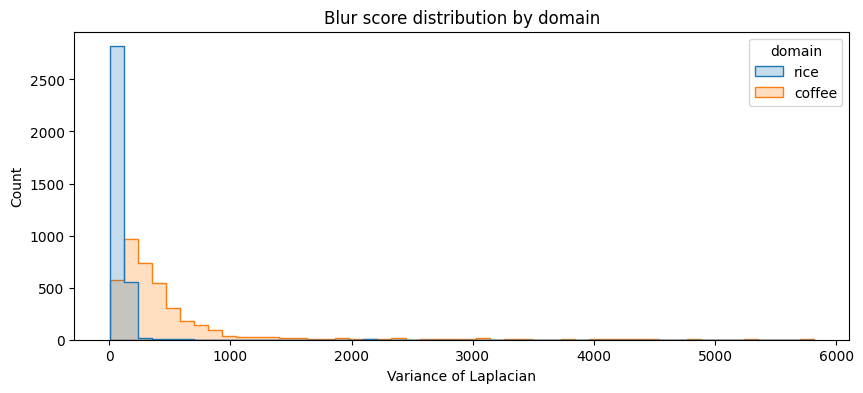

In [3]:
# ============================================================
# Data quality filtering
# ============================================================
BLUR_QUANTILE = 0.02
DROP_BLURRY = True


def compute_md5(file_path: str, chunk_size: int = 1 << 20) -> str:
    md5 = hashlib.md5()
    with open(file_path, "rb") as f:
        while True:
            chunk = f.read(chunk_size)
            if not chunk:
                break
            md5.update(chunk)
    return md5.hexdigest()


def estimate_blur_score(file_path: str) -> float:
    try:
        with Image.open(file_path) as img:
            gray = np.asarray(img.convert("L"), dtype=np.float32)
        if gray.shape[0] < 3 or gray.shape[1] < 3:
            return 0.0

        # Variance of Laplacian (discrete 4-neighborhood)
        lap = (
            -4.0 * gray[1:-1, 1:-1]
            + gray[:-2, 1:-1]
            + gray[2:, 1:-1]
            + gray[1:-1, :-2]
            + gray[1:-1, 2:]
        )
        return float(np.var(lap))
    except Exception:
        return np.nan


quality_df = meta_df.copy()
valid_idx = quality_df["is_valid_image"]

# File hash for duplicate detection
quality_df.loc[valid_idx, "md5"] = [
    compute_md5(p)
    for p in tqdm(quality_df.loc[valid_idx, "image_path"], desc="Hashing images")
]
quality_df["is_duplicate"] = quality_df["md5"].duplicated(keep="first")

# Blur score for quality control
quality_df.loc[valid_idx, "blur_score"] = [
    estimate_blur_score(p)
    for p in tqdm(quality_df.loc[valid_idx, "image_path"], desc="Scoring blur")
]

global_blur_threshold = quality_df.loc[valid_idx, "blur_score"].quantile(BLUR_QUANTILE)

def resolve_group_threshold(series: pd.Series) -> float:
    # Use class-specific threshold when enough samples are available.
    if series.notna().sum() >= 40:
        return float(series.quantile(BLUR_QUANTILE))
    return float(global_blur_threshold)

quality_df["blur_threshold"] = quality_df.groupby("domain_label")["blur_score"].transform(resolve_group_threshold)
quality_df["is_blurry"] = (quality_df["blur_score"] < quality_df["blur_threshold"]).fillna(False)

if DROP_BLURRY:
    keep_mask = quality_df["is_valid_image"] & (~quality_df["is_duplicate"]) & (~quality_df["is_blurry"])
else:
    keep_mask = quality_df["is_valid_image"] & (~quality_df["is_duplicate"])

clean_df = quality_df.loc[keep_mask].copy().reset_index(drop=True)

removed_summary = pd.DataFrame({
    "reason": ["invalid", "duplicate", "blurry", "kept"],
    "count": [
        int((~quality_df["is_valid_image"]).sum()),
        int(quality_df["is_duplicate"].sum()),
        int(quality_df["is_blurry"].sum()) if DROP_BLURRY else 0,
        int(len(clean_df)),
    ],
})
removed_summary["ratio_percent"] = (removed_summary["count"] / len(quality_df) * 100).round(2)

print(f"Global blur threshold (q={BLUR_QUANTILE:.2f}): {global_blur_threshold:.4f}")
display(removed_summary)

clean_dist = (
    clean_df.groupby(["domain", "label"], as_index=False)
    .agg(n_images=("sample_id", "count"))
    .sort_values(["domain", "label"])
)
display(clean_dist)

plt.figure(figsize=(10, 4))
sns.histplot(data=quality_df[quality_df["is_valid_image"]], x="blur_score", hue="domain", bins=50, element="step")
plt.title("Blur score distribution by domain")
plt.xlabel("Variance of Laplacian")
plt.ylabel("Count")
plt.show()

### Phân tích: Kết quả làm sạch dữ liệu

#### Kết quả lọc chất lượng

Từ bảng `removed_summary`, ta quan sát:

| Lý do loại | Ý nghĩa |
|------------|---------|
| **Invalid** | Ảnh corrupt → thường rất ít, nếu nhiều cần kiểm tra lại nguồn tải |
| **Duplicate** | Ảnh trùng nội dung → bộ dataset gốc có thể đã augment trước → cần loại để tránh leakage |
| **Blurry** | Ảnh mờ dưới ngưỡng 2% quantile theo lớp → loại bỏ mẫu chất lượng thấp nhất |
| **Kept** | Số mẫu sạch còn lại cho bước chia tập |

#### Phân tích phân phối blur score

Biểu đồ histogram của `blur_score` theo domain cho thấy:
- Nếu phân phối của một domain lệch về phía trái (VoL thấp) → domain đó có nhiều ảnh mờ hơn → có thể do điều kiện chụp thực địa.
- Ngưỡng 2% quantile đảm bảo chỉ loại những ảnh **cực kỳ** mờ, không quá aggressive với dữ liệu.
- Dùng ngưỡng **theo từng lớp** tránh tình trạng một lớp có ảnh vốn ít detail (ví dụ lá lúa healthy trơn) bị coi là mờ khi so với lớp có nhiều texture bệnh.

---

## 4. Chia dữ liệu chống leakage (Stratified Split)

Theo proposal, dữ liệu được chia theo tỉ lệ:
- Train: 70%
- Validation: 15%
- Test: 15%

Ta stratify theo `domain + label` để giữ cân bằng giữa lúa/cà phê và các lớp bệnh.

Sau khi chia, notebook kiểm tra chồng lấp theo cả `sample_id` và `md5` để đảm bảo không rò rỉ dữ liệu giữa các split.

### Vấn đề Data Leakage

**Data leakage** xảy ra khi thông tin từ tập validation/test "rò rỉ" vào tập train, khiến mô hình được đánh giá lạc quan hơn thực tế. Ở đây, leakage nghĩa là cùng một ảnh xuất hiện ở cả train lẫn val/test.

### Stratified Split (Chia tầng)

Stratified split đảm bảo **tỉ lệ phân phối lớp** trong mỗi tập giống nhau:

$$\frac{|\text{class}_i \cap \text{train}|}{|\text{train}|} \approx \frac{|\text{class}_i|}{|\text{dataset}|}$$

Ta stratify theo `domain + label` (ví dụ: `rice::healthy`, `coffee::leaf_rust`) để đảm bảo cả hai tiêu chí domain và nhãn bệnh đều cân bằng.

### Quy trình chia 2 bước

Để đạt tỉ lệ 70/15/15:

1. **Bước 1**: Tách train (70%) khỏi phần còn lại (30%) → `temp`.
2. **Bước 2**: Tách `temp` thành val (50%) và test (50%) → val = 15%, test = 15%.

### Kiểm tra chống leakage

Sau khi chia, notebook kiểm tra **overlap** theo cả `sample_id` (đường dẫn duy nhất) và `md5` (nội dung file) để đảm bảo tuyệt đối không có ảnh nào xuất hiện ở hai tập khác nhau.

In [4]:
# ============================================================
# Stratified split: train / val / test
# ============================================================
TRAIN_RATIO = 0.70
VAL_RATIO = 0.15
TEST_RATIO = 0.15

assert abs((TRAIN_RATIO + VAL_RATIO + TEST_RATIO) - 1.0) < 1e-9

stratify_col = clean_df["domain_label"]

train_df, temp_df = train_test_split(
    clean_df,
    test_size=(1.0 - TRAIN_RATIO),
    random_state=RANDOM_SEED,
    stratify=stratify_col,
)

val_share_of_temp = VAL_RATIO / (VAL_RATIO + TEST_RATIO)
val_df, test_df = train_test_split(
    temp_df,
    test_size=(1.0 - val_share_of_temp),
    random_state=RANDOM_SEED,
    stratify=temp_df["domain_label"],
)

train_df = train_df.copy()
val_df = val_df.copy()
test_df = test_df.copy()
train_df["split"] = "train"
val_df["split"] = "val"
test_df["split"] = "test"

split_df = pd.concat([train_df, val_df, test_df], ignore_index=True)

# Leakage checks by unique id and by image content hash
def overlap_size(left: pd.DataFrame, right: pd.DataFrame, key: str) -> int:
    return len(set(left[key]) & set(right[key]))

print("Overlap checks (must be 0):")
print(f"sample_id train-val : {overlap_size(train_df, val_df, 'sample_id')}")
print(f"sample_id train-test: {overlap_size(train_df, test_df, 'sample_id')}")
print(f"sample_id val-test  : {overlap_size(val_df, test_df, 'sample_id')}")
print(f"md5 train-val       : {overlap_size(train_df, val_df, 'md5')}")
print(f"md5 train-test      : {overlap_size(train_df, test_df, 'md5')}")
print(f"md5 val-test        : {overlap_size(val_df, test_df, 'md5')}")

split_stats = (
    split_df.groupby(["split", "domain", "label"], as_index=False)
    .agg(n_images=("sample_id", "count"))
    .sort_values(["split", "domain", "label"])
)
display(split_stats)

global_split_ratio = (
    split_df["split"].value_counts(normalize=True)
    .rename("ratio")
    .mul(100)
    .round(2)
    .sort_index()
)
print("Global split ratio (%):")
print(global_split_ratio.to_string())

# Save initial manifests immediately after split to lock anti-leakage partitions
for column in ["image_path", "relative_path"]:
    split_df[column] = split_df[column].astype(str).str.replace("\\\\", "/", regex=False)

meta_export_cols = [
    "sample_id", "split", "domain", "label", "domain_label", "class_folder",
    "file_name", "image_path", "relative_path",
    "width", "height", "aspect_ratio", "file_size_bytes",
    "md5", "blur_score",
    "is_valid_image", "is_duplicate", "is_blurry",
]

split_df.to_csv(META_DIR / "all_splits_manifest.csv", index=False, encoding="utf-8")
train_df[meta_export_cols].to_csv(META_DIR / "train_manifest.csv", index=False, encoding="utf-8")
val_df[meta_export_cols].to_csv(META_DIR / "val_manifest.csv", index=False, encoding="utf-8")
test_df[meta_export_cols].to_csv(META_DIR / "test_manifest.csv", index=False, encoding="utf-8")

print(f"Saved initial split manifests to: {META_DIR}")

Overlap checks (must be 0):
sample_id train-val : 0
sample_id train-test: 0
sample_id val-test  : 0
md5 train-val       : 0
md5 train-test      : 0
md5 val-test        : 0


,split,domain,label,n_images
0,test,coffee,AlgalLeafSpot,143
1,test,coffee,LeafMiner,180
2,test,coffee,PowderyMildew,39
3,test,coffee,Rust,208
4,test,rice,BrownSpot,79
5,test,rice,Healthy,221
6,test,rice,Hispa,86
7,test,rice,LeafBlast,117
8,train,coffee,AlgalLeafSpot,664
9,train,coffee,LeafMiner,840


Global split ratio (%):
split
test     15.01
train    70.00
val      15.00
Saved initial split manifests to: c:\Users\tdat0\Data\Uncategorized_items\ml-vietnam-plant-disease-detection\datasets\processed\metadata


---

## 5. Chuẩn hóa ảnh và lưu vào `data/processed/images`

Theo insight EDA về đa dạng kích thước/tỉ lệ ảnh, ta dùng pipeline chuẩn hóa tĩnh:
1. Đọc ảnh RGB
2. Resize theo cạnh dài về kích thước chuẩn
3. Padding để giữ tỉ lệ ảnh (tránh méo hình)
4. Lưu ảnh đã chuẩn hóa theo cấu trúc split

Cấu trúc lưu trữ:
- `data/processed/images/train/<domain>/<label>/...`
- `data/processed/images/val/<domain>/<label>/...`
- `data/processed/images/test/<domain>/<label>/...`

### Vấn đề: Ảnh đa dạng kích thước

Dữ liệu thực tế có ảnh với kích thước và tỉ lệ khung hình (aspect ratio) rất khác nhau. Các mạng CNN/ViT yêu cầu input có kích thước cố định.

### Hai cách tiếp cận phổ biến

| Phương pháp | Ưu điểm | Nhược điểm |
|-------------|---------|-----------|
| **Resize trực tiếp** | Đơn giản | Méo hình (distortion) |
| **Resize + Padding** | Giữ tỉ lệ gốc | Thêm pixel đen viền |

### Resize giữ tỉ lệ + Padding (phương pháp được dùng)

**Bước 1 — Scale theo cạnh dài:**

$$\text{scale} = \frac{\text{canvas\_size}}{\max(W, H)}$$

$$W' = \lfloor W \cdot \text{scale} \rceil, \quad H' = \lfloor H \cdot \text{scale} \rceil$$

**Bước 2 — Padding đối xứng về canvas vuông:**

$$\text{pad\_w} = \text{canvas\_size} - W', \quad \text{pad\_h} = \text{canvas\_size} - H'$$

Padding phân bổ đều hai bên: `left = pad_w // 2`, `right = pad_w - pad_w // 2`.

**Kết quả**: Ảnh luôn có kích thước `256×256` với viền đen đối xứng — không méo hình.

### Bộ lọc BICUBIC

Resize dùng bộ lọc **BICUBIC** (nội suy bicubic bởi 16 pixel lân cận), cho chất lượng tốt hơn BILINEAR và NEAREST khi thu nhỏ ảnh.

In [5]:
# ============================================================
# Export standardized images to data/processed/images
# ============================================================
TARGET_CANVAS_SIZE = 256
EXPORT_IMAGE_FORMAT = "JPEG"
EXPORT_JPEG_QUALITY = 95
OVERWRITE_EXISTING = False


def label_to_dirname(label: str) -> str:
    return label.strip().replace(" ", "_").replace("/", "-")


def resize_with_padding(img: Image.Image, canvas_size: int = 256) -> Image.Image:
    img = img.convert("RGB")
    width, height = img.size
    scale = canvas_size / max(width, height)
    new_w = max(1, int(round(width * scale)))
    new_h = max(1, int(round(height * scale)))

    resized = img.resize((new_w, new_h), resample=Image.Resampling.BICUBIC)

    pad_w = canvas_size - new_w
    pad_h = canvas_size - new_h
    padding = (pad_w // 2, pad_h // 2, pad_w - pad_w // 2, pad_h - pad_h // 2)
    return ImageOps.expand(resized, border=padding, fill=(0, 0, 0))


processed_rows = []
failed_rows = []

for row in tqdm(split_df.itertuples(index=False), total=len(split_df), desc="Export standardized images"):
    src_path = PROJECT_ROOT / Path(row.relative_path)
    out_dir = IMG_OUT_DIR / row.split / row.domain / label_to_dirname(row.label)
    out_dir.mkdir(parents=True, exist_ok=True)
    out_file = out_dir / f"{row.sample_id}.jpg"

    try:
        if OVERWRITE_EXISTING or (not out_file.exists()):
            with Image.open(src_path) as img:
                standardized = resize_with_padding(img, canvas_size=TARGET_CANVAS_SIZE)
                standardized.save(
                    out_file,
                    format=EXPORT_IMAGE_FORMAT,
                    quality=EXPORT_JPEG_QUALITY,
                    optimize=True,
                )

        processed_rows.append({
            "sample_id": row.sample_id,
            "processed_relative_path": str(out_file.relative_to(PROJECT_ROOT)).replace("\\", "/"),
        })
    except Exception as ex:
        failed_rows.append({
            "sample_id": row.sample_id,
            "image_path": row.image_path,
            "error": str(ex),
        })

processed_map_df = pd.DataFrame(processed_rows)
failed_df = pd.DataFrame(failed_rows)

if len(failed_df) > 0:
    print(f"[WARN] Failed to process {len(failed_df)} images. These rows will be excluded.")
    display(failed_df.head())
    split_df = split_df[~split_df["sample_id"].isin(failed_df["sample_id"])].copy()

split_df = split_df.merge(processed_map_df, on="sample_id", how="left")
split_df = split_df.dropna(subset=["processed_relative_path"]).copy().reset_index(drop=True)

export_summary = (
    split_df.groupby(["split", "domain", "label"], as_index=False)
    .agg(n_images=("sample_id", "count"))
    .sort_values(["split", "domain", "label"])
)
display(export_summary)

# Save manifests after image export
split_df.to_csv(META_DIR / "all_splits_manifest.csv", index=False, encoding="utf-8")
for split_name in ["train", "val", "test"]:
    split_df[split_df["split"] == split_name].to_csv(
        META_DIR / f"{split_name}_manifest.csv",
        index=False,
        encoding="utf-8",
    )

if len(failed_df) > 0:
    failed_df.to_csv(META_DIR / "failed_images.csv", index=False, encoding="utf-8")

print(f"Export complete. Image root: {IMG_OUT_DIR}")
print(f"Updated manifest files: {META_DIR}")

Export standardized images: 100%|██████████| 7149/7149 [00:03<00:00, 1787.59it/s]


,split,domain,label,n_images
0,test,coffee,AlgalLeafSpot,143
1,test,coffee,LeafMiner,180
2,test,coffee,PowderyMildew,39
3,test,coffee,Rust,208
4,test,rice,BrownSpot,79
5,test,rice,Healthy,221
6,test,rice,Hispa,86
7,test,rice,LeafBlast,117
8,train,coffee,AlgalLeafSpot,664
9,train,coffee,LeafMiner,840


Export complete. Image root: c:\Users\tdat0\Data\Uncategorized_items\ml-vietnam-plant-disease-detection\datasets\processed\images
Updated manifest files: c:\Users\tdat0\Data\Uncategorized_items\ml-vietnam-plant-disease-detection\datasets\processed\metadata


---

## 6. Tính thống kê chuẩn hóa (mean/std) trên train split

Để tránh leakage, thống kê chuẩn hóa chỉ được tính từ tập train sau khi đã split và chuẩn hóa kích thước.

Kết quả sẽ được lưu tại:
- `data/processed/metadata/normalization_stats.json`

### Pixel Normalization

Sau khi resize, pixel có giá trị trong $[0, 255]$. Ta chuẩn hóa về phân phối chuẩn:

$$\hat{x}_c = \frac{x_c / 255 - \mu_c}{\sigma_c}$$

Trong đó $c \in \{R, G, B\}$ là từng kênh màu, và $\mu_c, \sigma_c$ là **mean** và **standard deviation** tính trên tập train.

### Công thức tính Online (Welford-like)

Thay vì load toàn bộ ảnh vào RAM, ta tính theo batch:

$$\mu_c = \frac{\sum_{i,x,y} I_c(i,x,y)}{N_{\text{total\_pixels}}}$$

$$\sigma_c = \sqrt{\frac{\sum_{i,x,y} I_c^2(i,x,y)}{N_{\text{total\_pixels}}} - \mu_c^2}$$

Đây là công thức tính phương sai từ moment bậc 1 và bậc 2.

### Tại sao chỉ dùng train split?

Nếu tính mean/std trên toàn bộ dataset (bao gồm val/test), thông tin thống kê của val/test sẽ "rò rỉ" vào pipeline preprocessing — đây là dạng **data leakage**. Chỉ tính trên train đảm bảo val/test là dữ liệu hoàn toàn unseen.

In [6]:
# ============================================================
# Compute channel mean/std from train split only
# ============================================================
def compute_channel_mean_std(image_paths: List[Path]):
    channel_sum = np.zeros(3, dtype=np.float64)
    channel_sq_sum = np.zeros(3, dtype=np.float64)
    total_pixels = 0

    for img_path in tqdm(image_paths, desc="Computing mean/std"):
        with Image.open(img_path) as img:
            arr = np.asarray(img.convert("RGB"), dtype=np.float32) / 255.0
        pixels = arr.reshape(-1, 3)
        channel_sum += pixels.sum(axis=0)
        channel_sq_sum += np.square(pixels).sum(axis=0)
        total_pixels += pixels.shape[0]

    mean = channel_sum / total_pixels
    std = np.sqrt(channel_sq_sum / total_pixels - np.square(mean))
    return mean, std

train_paths = [
    PROJECT_ROOT / Path(p)
    for p in split_df.loc[split_df["split"] == "train", "processed_relative_path"].tolist()
]

train_mean, train_std = compute_channel_mean_std(train_paths)

normalization_stats = {
    "source": "train_split_only",
    "num_images": int(len(train_paths)),
    "mean": [float(x) for x in train_mean],
    "std": [float(x) for x in train_std],
}

with open(META_DIR / "normalization_stats.json", "w", encoding="utf-8") as f:
    json.dump(normalization_stats, f, ensure_ascii=False, indent=2)

print("Train normalization stats:")
print(json.dumps(normalization_stats, ensure_ascii=False, indent=2))

Computing mean/std: 100%|██████████| 5004/5004 [00:28<00:00, 172.64it/s]

Train normalization stats:
{
  "source": "train_split_only",
  "num_images": 5004,
  "mean": [
    0.5457740308274682,
    0.5713113648094814,
    0.5405287954611607
  ],
  "std": [
    0.32260145825733094,
    0.3160803815505878,
    0.3574995634745441
  ]
}


---

## 7. Thiết lập augmentation cho train/val/test

Dựa trên EDA và yêu cầu trong đề bài/proposal, train transform gồm:
- Random affine
- Intensity transformation (color jitter)
- Flip/rotation
- Cutout (Random Erasing)
- MixUp/CutMix (áp dụng ở mức batch trong vòng train)

Validation/Test chỉ dùng transform xác định (deterministic) để đánh giá công bằng.

Data augmentation tạo ra các biến thể của ảnh gốc trong quá trình training, giúp mô hình học được **biểu diễn bất biến** (invariant representations) và tăng tính tổng quát hóa.

### Geometric Augmentation (Biến đổi hình học)

| Kỹ thuật | Mục đích |
|----------|---------|
| **RandomResizedCrop** | Mô phỏng góc nhìn / zoom khác nhau |
| **RandomHorizontalFlip** | Lá cây không phân biệt trái/phải |
| **RandomVerticalFlip** | Ảnh chụp từ nhiều góc |
| **RandomAffine** | Xoay, dịch chuyển, biến dạng nhẹ |

### Photometric Augmentation (Biến đổi màu sắc)

**ColorJitter** thay đổi ngẫu nhiên 4 thuộc tính màu:
- **Brightness** ($\beta$): $I' = I \cdot (1 + \delta_\beta)$
- **Contrast** ($\gamma$): $I' = (I - \mu) \cdot (1 + \delta_\gamma) + \mu$
- **Saturation**: Tăng/giảm độ bão hòa màu trong không gian HSV.
- **Hue**: Dịch chuyển góc màu trong không gian HSV.

### Cutout / Random Erasing

Masking ngẫu nhiên một vùng hình chữ nhật bằng giá trị ngẫu nhiên:

$$I'_{\text{patch}} = \text{random noise}$$

Kỹ thuật này buộc mô hình không phụ thuộc vào một vùng ảnh cụ thể.

### MixUp

Trộn hai ảnh $(x_i, y_i)$ và $(x_j, y_j)$ theo tham số $\lambda \sim \text{Beta}(\alpha, \alpha)$:

$$\tilde{x} = \lambda x_i + (1-\lambda) x_j, \quad \tilde{y} = \lambda y_i + (1-\lambda) y_j$$

MixUp tạo ra **soft labels**, khuyến khích mô hình học biểu diễn trơn mượt hơn.

### CutMix

Thay vì trộn pixel toàn ảnh như MixUp, CutMix dán một **vùng cắt từ ảnh $j$** lên ảnh $i$:

$$\tilde{x} = \mathbf{M} \odot x_i + (1 - \mathbf{M}) \odot x_j$$

Trong đó $\mathbf{M}$ là mask nhị phân xác định vùng cắt. Nhãn được điều chỉnh theo tỉ lệ diện tích:

$$\tilde{y} = \lambda_{\text{adj}} \cdot y_i + (1 - \lambda_{\text{adj}}) \cdot y_j, \quad \lambda_{\text{adj}} = 1 - \frac{(x_2-x_1)(y_2-y_1)}{W \cdot H}$$

CutMix kết hợp ưu điểm của **Cutout** (regularization cục bộ) và **MixUp** (soft labels).

### Eval Transform (Deterministic)

Validation/Test **không dùng augmentation ngẫu nhiên** — chỉ dùng `CenterCrop` cố định để đánh giá công bằng và tái lập được.

In [7]:
# ============================================================
# Define transforms + batch-level MixUp/CutMix helpers
# ============================================================
from torchvision import transforms as T

NORM_MEAN = normalization_stats["mean"]
NORM_STD = normalization_stats["std"]
TRAIN_CROP_SIZE = 224

train_transform = T.Compose([
    T.RandomResizedCrop(size=TRAIN_CROP_SIZE, scale=(0.75, 1.0), ratio=(0.9, 1.1)),
    T.RandomHorizontalFlip(p=0.5),
    T.RandomVerticalFlip(p=0.2),
    T.RandomAffine(degrees=30, translate=(0.08, 0.08), scale=(0.9, 1.1), shear=10),
    T.ColorJitter(brightness=0.3, contrast=0.3, saturation=0.2, hue=0.05),
    T.ToTensor(),
    T.RandomErasing(p=0.5, scale=(0.02, 0.15), ratio=(0.3, 3.3), value="random"),
    T.Normalize(mean=NORM_MEAN, std=NORM_STD),
])

eval_transform = T.Compose([
    T.CenterCrop(size=TRAIN_CROP_SIZE),
    T.ToTensor(),
    T.Normalize(mean=NORM_MEAN, std=NORM_STD),
])


def one_hot(labels: torch.Tensor, num_classes: int) -> torch.Tensor:
    return torch.nn.functional.one_hot(labels, num_classes=num_classes).float()


def sample_beta(alpha: float) -> float:
    if alpha <= 0:
        return 1.0
    return float(np.random.beta(alpha, alpha))


def mixup_batch(
    images: torch.Tensor,
    labels: torch.Tensor,
    num_classes: int,
    alpha: float = 0.4,
    device: str = "cpu",
):
    lam = sample_beta(alpha)
    indices = torch.randperm(images.size(0), device=images.device)
    mixed_images = lam * images + (1 - lam) * images[indices]

    labels_a = one_hot(labels, num_classes).to(device)
    labels_b = one_hot(labels[indices], num_classes).to(device)
    mixed_labels = lam * labels_a + (1 - lam) * labels_b
    return mixed_images, mixed_labels


def rand_bbox(width: int, height: int, lam: float):
    cut_ratio = np.sqrt(1.0 - lam)
    cut_w = int(width * cut_ratio)
    cut_h = int(height * cut_ratio)

    cx = np.random.randint(0, width)
    cy = np.random.randint(0, height)

    x1 = np.clip(cx - cut_w // 2, 0, width)
    y1 = np.clip(cy - cut_h // 2, 0, height)
    x2 = np.clip(cx + cut_w // 2, 0, width)
    y2 = np.clip(cy + cut_h // 2, 0, height)
    return x1, y1, x2, y2


def cutmix_batch(
    images: torch.Tensor,
    labels: torch.Tensor,
    num_classes: int,
    alpha: float = 1.0,
    device: str = "cpu",
):
    lam = sample_beta(alpha)
    indices = torch.randperm(images.size(0), device=images.device)

    _, _, h, w = images.shape
    x1, y1, x2, y2 = rand_bbox(width=w, height=h, lam=lam)

    mixed_images = images.clone()
    mixed_images[:, :, y1:y2, x1:x2] = images[indices, :, y1:y2, x1:x2]

    box_area = (x2 - x1) * (y2 - y1)
    lam_adjusted = 1.0 - (box_area / float(w * h))

    labels_a = one_hot(labels, num_classes).to(device)
    labels_b = one_hot(labels[indices], num_classes).to(device)
    mixed_labels = lam_adjusted * labels_a + (1 - lam_adjusted) * labels_b
    return mixed_images, mixed_labels

print("Train transform:", train_transform)
print("Eval transform:", eval_transform)

Train transform: Compose(
    RandomResizedCrop(size=(224, 224), scale=(0.75, 1.0), ratio=(0.9, 1.1), interpolation=bilinear, antialias=True)
    RandomHorizontalFlip(p=0.5)
    RandomVerticalFlip(p=0.2)
    RandomAffine(degrees=[-30.0, 30.0], translate=(0.08, 0.08), scale=(0.9, 1.1), shear=[-10.0, 10.0])
    ColorJitter(brightness=(0.7, 1.3), contrast=(0.7, 1.3), saturation=(0.8, 1.2), hue=(-0.05, 0.05))
    ToTensor()
    RandomErasing(p=0.5, scale=(0.02, 0.15), ratio=(0.3, 3.3), value=random, inplace=False)
    Normalize(mean=[0.5457740308274682, 0.5713113648094814, 0.5405287954611607], std=[0.32260145825733094, 0.3160803815505878, 0.3574995634745441])
)
Eval transform: Compose(
    CenterCrop(size=(224, 224))
    ToTensor()
    Normalize(mean=[0.5457740308274682, 0.5713113648094814, 0.5405287954611607], std=[0.32260145825733094, 0.3160803815505878, 0.3574995634745441])
)


### Phân tích: Thiết kế augmentation pipeline

#### Lựa chọn các kỹ thuật augmentation

Các kỹ thuật được chọn phù hợp với đặc điểm bài toán phát hiện bệnh lá cây:

| Kỹ thuật | Lý do chọn | Tham số |
|----------|-----------|---------|
| **RandomResizedCrop(0.75–1.0)** | Lá cây ở các góc nhìn/zoom khác nhau | Scale cao → không mất quá nhiều thông tin |
| **HorizontalFlip(p=0.5)** | Đối xứng sinh học — lá trái/phải như nhau | Standard |
| **VerticalFlip(p=0.2)** | Ảnh chụp có thể bị ngược | Xác suất thấp hơn flip ngang |
| **RandomAffine(±30°)** | Góc chụp đa dạng ngoài thực địa | Không quá extreme để không tạo artifact |
| **ColorJitter(b=0.3, c=0.3)** | Điều kiện ánh sáng thay đổi theo ngày/mùa | Moderate intensity |
| **RandomErasing(p=0.5)** | Che khuất một phần lá → regularization | Scale nhỏ (0.02–0.15) để không xóa quá nhiều |
| **MixUp(α=0.4)** | Soft labels → mô hình confident hơn | α=0.4 → blend mạnh |
| **CutMix(α=1.0)** | Tăng đa dạng feature | α=1.0 → cut ratio đa dạng đều |

#### Eval Transform: chỉ CenterCrop

Validation và test chỉ dùng `CenterCrop(224)` — đây là lựa chọn **deterministic** đảm bảo:
- Mỗi lần inference trên cùng một ảnh → cùng kết quả.
- Crop từ trung tâm của ảnh đã padding 256×256 → lấy phần trung tâm 224×224 (không có padding đen).

#### Lưu ý về MixUp/CutMix

MixUp và CutMix được thực hiện ở **mức batch** trong vòng lặp training (không phải trong `Dataset.__getitem__`), vì chúng cần trộn 2 samples. Các hàm `mixup_batch` và `cutmix_batch` sẽ được gọi trong notebook huấn luyện.

---

## 8. Cân bằng lớp cho train loader và lưu cấu hình tiền xử lý

Do dữ liệu mất cân bằng (đặc biệt ở domain cà phê), ta tạo `WeightedRandomSampler` để tăng xác suất lấy mẫu từ lớp thiểu số trong train loader.

Ngoài ra notebook sẽ lưu file cấu hình tiền xử lý để đảm bảo các notebook huấn luyện/evaluation dùng lại đúng tham số đã chuẩn hóa.

### Vấn đề mất cân bằng dữ liệu (Class Imbalance)

Nếu một lớp có số lượng mẫu lớn hơn nhiều so với các lớp khác, mô hình sẽ thiên về lớp đa số (majority bias) và bỏ qua lớp thiểu số.

Trong bài toán phát hiện bệnh lá cây, điều này rất nguy hiểm: mô hình có thể luôn dự đoán "healthy" và đạt accuracy cao nhưng không phát hiện được bệnh thực sự.

### WeightedRandomSampler

`WeightedRandomSampler` của PyTorch gán **trọng số lấy mẫu** cho từng sample, sao cho mỗi lớp có xác suất xuất hiện bằng nhau trong mỗi mini-batch.

**Trọng số nghịch đảo tần suất (Inverse-frequency weighting):**

$$w_c = \frac{1}{|\mathcal{D}_{\text{train}}^c|}$$

Trong đó $|\mathcal{D}_{\text{train}}^c|$ là số lượng mẫu của lớp $c$ trong tập train.

**Xác suất lấy mẫu mẫu $i$ thuộc lớp $c$:**

$$P(i) = \frac{w_c}{\sum_j w_{y_j}}$$

Sampler sử dụng `replacement=True` — tức là **oversampling** các lớp thiểu số bằng cách lấy mẫu lặp lại.

### Preprocessing Config JSON

File `preprocessing_config.json` lưu toàn bộ siêu tham số của pipeline tiền xử lý. Mục đích:
- Đảm bảo các notebook con (training, evaluation) dùng **đúng tham số** đã được chuẩn hóa.
- Hỗ trợ **versioning**: khi thay đổi tham số, có thể so sánh các config cũ/mới.
- Giúp **tái tạo** toàn bộ pipeline từ đầu chỉ cần một file config.

In [8]:
# ============================================================
# Build class mapping, weighted sampler, and save preprocessing config
# ============================================================
from torch.utils.data import WeightedRandomSampler

GLOBAL_CLASS_ORDER = RICE_CLASSES + COFFEE_CLASSES
class_to_index = {label: idx for idx, label in enumerate(GLOBAL_CLASS_ORDER)}

unknown_labels = sorted(set(split_df["label"]) - set(class_to_index.keys()))
if len(unknown_labels) > 0:
    raise ValueError(f"Unknown labels detected: {unknown_labels}")

split_df["label_idx"] = split_df["label"].map(class_to_index).astype(int)

train_manifest_df = split_df[split_df["split"] == "train"].copy().reset_index(drop=True)
train_label_counts = train_manifest_df["label"].value_counts().sort_index()

# Inverse-frequency weighting
class_weight_map = {label: 1.0 / count for label, count in train_label_counts.items()}
sample_weights = train_manifest_df["label"].map(class_weight_map).values
train_sampler = WeightedRandomSampler(
    weights=torch.as_tensor(sample_weights, dtype=torch.double),
    num_samples=len(sample_weights),
    replacement=True,
)

weight_table = pd.DataFrame({
    "label": list(class_weight_map.keys()),
    "class_count": [int(train_label_counts[label]) for label in class_weight_map.keys()],
    "sampling_weight": [float(class_weight_map[label]) for label in class_weight_map.keys()],
}).sort_values("label")
display(weight_table)

# Persist final manifests (with label_idx + processed path)
split_df.to_csv(META_DIR / "all_splits_manifest.csv", index=False, encoding="utf-8")
for split_name in ["train", "val", "test"]:
    split_df[split_df["split"] == split_name].to_csv(
        META_DIR / f"{split_name}_manifest.csv",
        index=False,
        encoding="utf-8",
    )

preprocessing_config = {
    "random_seed": int(RANDOM_SEED),
    "split_ratio": {
        "train": TRAIN_RATIO,
        "val": VAL_RATIO,
        "test": TEST_RATIO,
    },
    "quality_filter": {
        "drop_blurry": bool(DROP_BLURRY),
        "blur_quantile": float(BLUR_QUANTILE),
    },
    "standardization": {
        "canvas_size": int(TARGET_CANVAS_SIZE),
        "crop_size": int(TRAIN_CROP_SIZE),
        "mean": [float(x) for x in NORM_MEAN],
        "std": [float(x) for x in NORM_STD],
    },
    "augmentation_train": {
        "random_resized_crop_scale": [0.75, 1.0],
        "random_resized_crop_ratio": [0.9, 1.1],
        "horizontal_flip_prob": 0.5,
        "vertical_flip_prob": 0.2,
        "random_affine": {
            "degrees": 30,
            "translate": [0.08, 0.08],
            "scale": [0.9, 1.1],
            "shear": 10,
        },
        "color_jitter": {
            "brightness": 0.3,
            "contrast": 0.3,
            "saturation": 0.2,
            "hue": 0.05,
        },
        "cutout_random_erasing": {
            "prob": 0.5,
            "scale": [0.02, 0.15],
            "ratio": [0.3, 3.3],
        },
        "mixup_alpha": 0.4,
        "cutmix_alpha": 1.0,
    },
    "class_to_index": class_to_index,
    "outputs": {
        "image_root": str(IMG_OUT_DIR.relative_to(PROJECT_ROOT)).replace("\\", "/"),
        "manifest_dir": str(META_DIR.relative_to(PROJECT_ROOT)).replace("\\", "/"),
        "train_manifest": "train_manifest.csv",
        "val_manifest": "val_manifest.csv",
        "test_manifest": "test_manifest.csv",
    },
}

with open(META_DIR / "preprocessing_config.json", "w", encoding="utf-8") as f:
    json.dump(preprocessing_config, f, ensure_ascii=False, indent=2)

print(f"Final manifests saved in: {META_DIR}")
print("Saved config file: preprocessing_config.json")
print(f"Weighted sampler length: {len(sample_weights):,}")

,label,class_count,sampling_weight
0,AlgalLeafSpot,664,0.001506
1,BrownSpot,372,0.002688
2,Healthy,1030,0.000971
3,Hispa,400,0.002500
4,LeafBlast,544,0.001838
5,LeafMiner,840,0.001190
6,PowderyMildew,183,0.005464
7,Rust,971,0.001030


Final manifests saved in: c:\Users\tdat0\Data\Uncategorized_items\ml-vietnam-plant-disease-detection\datasets\processed\metadata
Saved config file: preprocessing_config.json
Weighted sampler length: 5,004


---

## 9. Kết luận và đầu ra của notebook

Sau khi chạy xong toàn bộ notebook, đã có:
- Bộ ảnh đã chuẩn hóa theo split trong `data/processed/images/`.
- Các manifest chống leakage trong `data/processed/metadata/`:
  - `train_manifest.csv`
  - `val_manifest.csv`
  - `test_manifest.csv`
- Thống kê chuẩn hóa train-only: `normalization_stats.json`.
- Cấu hình tiền xử lý thống nhất: `preprocessing_config.json`.

Các đầu ra này là nền tảng cho các notebook huấn luyện/đánh giá tiếp theo (Phase Model Training & Evaluation), đồng thời đáp ứng yêu cầu workflow end-to-end của đồ án.